# LargeConv: multiresolution large-kernel tests

This notebook validates the learned `Down x L -> compact HealPixConv -> Up x L` implementation. It checks automatic kernel planning, partial NESTED patches, shuffled cell ordering, constant preservation, receptive field, CUDA/autograd and a small teacher/student training problem.

In [1]:
%load_ext autoreload
%autoreload 2

import copy
import time

import healpix_geo
import matplotlib.pyplot as plt
import numpy as np
import torch

from healpix_analyse import LargeConv

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(0)
np.random.seed(0)
print("device:", device)

device: cuda


## Build a partial NESTED patch

The identifiers are shuffled deliberately. `LargeConv` sorts them for its sparse multiresolution operators and restores this original order before returning. The patch is wider than the nominal 33-pixel receptive field to leave an interior region for visual inspection.

In [2]:
LEVEL = 6
NSIDE = 2**LEVEL
CENTRE = (30.0, 20.0)
RADIUS_DEG = 35.0

cell_ids, _, _ = healpix_geo.nested.cone_coverage(
    CENTRE, RADIUS_DEG, LEVEL, ellipsoid="sphere"
)
cell_ids = np.asarray(cell_ids, dtype=np.int64)
rng = np.random.default_rng(42)
rng.shuffle(cell_ids)
lon, lat = healpix_geo.nested.healpix_to_lonlat(
    cell_ids, LEVEL, ellipsoid="sphere"
)
lon = np.asarray(lon)
lat = np.asarray(lat)
print("patch cells:", len(cell_ids))

patch cells: 4682


## Automatic 33x33 plan

A fine radius of 16 pixels becomes a radius of 2 pixels after three resolution reductions, hence a compact 5x5 kernel. Two reductions would still require 9x9 and would exceed the configured limit of 7.

In [3]:
start = time.perf_counter()
layer = LargeConv(
    level=LEVEL,
    in_channels=1,
    out_channels=1,
    kernel_sz=33,
    max_compact_kernel_sz=7,
    cell_ids=cell_ids,
    ellipsoid="sphere",
    weight_norm="l1",
    up_norm="col_l1",
    device=device,
    dtype=torch.float32,
)
construction_seconds = time.perf_counter() - start

assert layer.n_levels == 3
assert layer.compact_kernel_sz == 5
assert layer.coarse_nside == NSIDE // 8
assert layer.effective_kernel_sz == 33
assert layer.weight.shape == (1, 1, 1, 25)
for down, up in zip(reversed(layer.down_layers), layer.up_layers):
    down_matrix = torch.sparse_coo_tensor(
        down._M_indices, down._M_values, size=down._M_size, device=device
    ).coalesce()
    expected_up = down_matrix.transpose(0, 1).coalesce()
    actual_up = torch.sparse_coo_tensor(
        up._M_indices, up._M_values, size=up._M_size, device=device
    ).coalesce()
    assert torch.equal(actual_up.indices(), expected_up.indices())
    assert torch.allclose(actual_up.values(), expected_up.values())
    assert np.array_equal(up.cell_ids_out, down._cell_ids_in)
print(layer)
print(f"construction: {construction_seconds:.3f} s")
print("fine pixels by level:", [len(cell_ids)] + [down.N_out for down in layer.down_layers])
direct_terms = len(cell_ids) * 33**2
compact_terms = layer.conv.K * layer.compact_kernel_sz**2
print(f"nominal gather-term reduction: {direct_terms / compact_terms:.1f}x")

LargeConv(
  level=6, nside=64, in=1, out=1, requested_kernel=33, compact_kernel=5, levels=3, effective_kernel=33, gauges=1, partial=True
  (down_layers): ModuleList(
    (0-2): 3 x HealPixDown()
  )
  (conv): HealPixConv(level=3, nside=8, in=1, out=1, kernel_sz=5, P=25, G=1, gauge='phi', partial=True)
  (up_layers): ModuleList(
    (0-2): 3 x HealPixUp()
  )
)
construction: 0.324 s
fine pixels by level: [4682, 1211, 324, 93]
nominal gather-term reduction: 2193.0x


## Constant preservation

The compact kernel is set to a centred unit impulse. Any remaining difference from one is caused by the Down/Up round trip and partial-patch boundaries, not by a resized kernel.

In [4]:
compact_weight = np.zeros((1, 1, 25), dtype=np.float32)
compact_weight[0, 0, 12] = 1.0
layer.set_compact_kernel(compact_weight, bias=np.zeros(1), requires_grad=True)

constant = torch.ones(len(cell_ids), device=device)
constant_out = layer(constant)
constant_error = (constant_out - constant).abs()
print("constant mean absolute error:", constant_error.mean().item())
print("constant maximum absolute error:", constant_error.max().item())
assert constant_out.shape == constant.shape
assert torch.isfinite(constant_out).all()

constant mean absolute error: 5.933729951834721e-08
constant maximum absolute error: 2.980232238769531e-07


## Shapes, batches and autograd

In [5]:
batch = torch.randn(3, 1, len(cell_ids), device=device, requires_grad=True)
output = layer(batch)
loss = output.square().mean()
loss.backward()

assert output.shape == (3, 1, len(cell_ids))
assert batch.grad is not None and torch.isfinite(batch.grad).all()
assert layer.weight.grad is not None and torch.isfinite(layer.weight.grad).all()
print("output shape:", tuple(output.shape))
print("input gradient norm:", batch.grad.norm().item())
print("kernel gradient norm:", layer.weight.grad.norm().item())

output shape: (3, 1, 4682)
input gradient norm: 0.00044165970757603645
kernel gradient norm: 0.008403155952692032


## Effective receptive field

An impulse is placed at the cell closest to the requested patch centre. The response visualises the effective fine-resolution kernel, including all smoothing and interpolation performed by Down and Up.

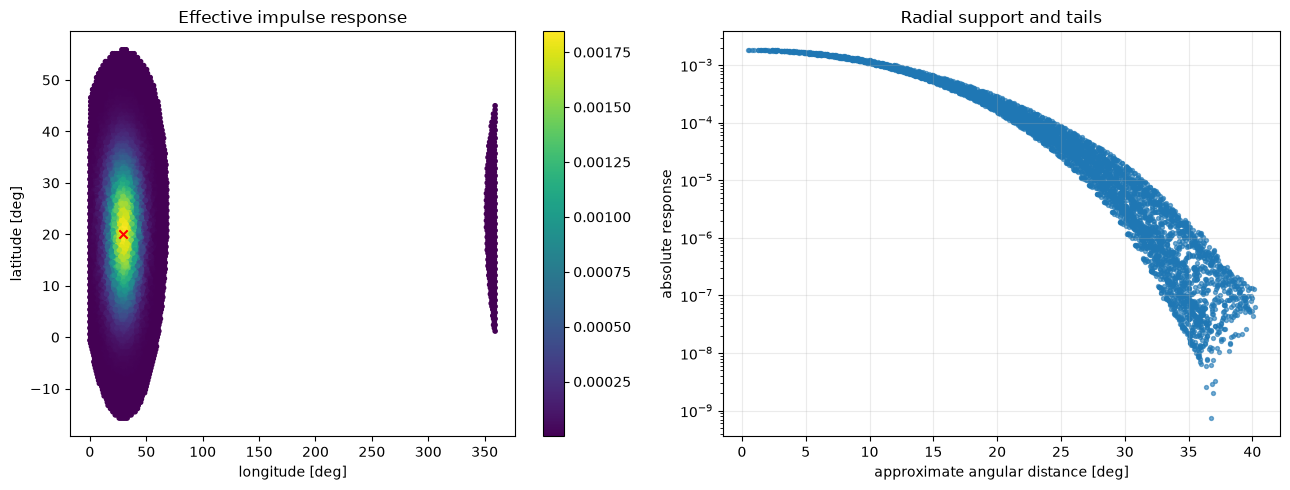

In [6]:
dlon = ((lon - CENTRE[0] + 180.0) % 360.0) - 180.0
centre_index = np.argmin(dlon**2 + (lat - CENTRE[1])**2)
impulse = torch.zeros(len(cell_ids), device=device)
impulse[centre_index] = 1.0
response = layer(impulse).detach().cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
points = axes[0].scatter(lon, lat, c=response, s=9, cmap="viridis")
axes[0].scatter(lon[centre_index], lat[centre_index], marker="x", c="red")
axes[0].set_xlabel("longitude [deg]")
axes[0].set_ylabel("latitude [deg]")
axes[0].set_title("Effective impulse response")
plt.colorbar(points, ax=axes[0])
distance = np.sqrt(dlon**2 + (lat - CENTRE[1])**2)
axes[1].scatter(distance, np.abs(response), s=8, alpha=0.6)
axes[1].set_yscale("log")
axes[1].set_xlabel("approximate angular distance [deg]")
axes[1].set_ylabel("absolute response")
axes[1].set_title("Radial support and tails")
axes[1].grid(True, alpha=0.25)
plt.tight_layout()

## End-to-end learning of the compact kernel

A frozen teacher and a trainable student share the same Down/Up geometry but use different compact kernels. Decreasing loss demonstrates that the compact weights are learned through the complete effective large convolution.

step 00: 3.793793e-03
step 01: 2.464888e-04
step 02: 1.611137e-03
step 03: 2.018646e-03
step 04: 1.018261e-03
step 05: 1.871863e-04
step 06: 2.378205e-04
step 07: 7.755454e-04


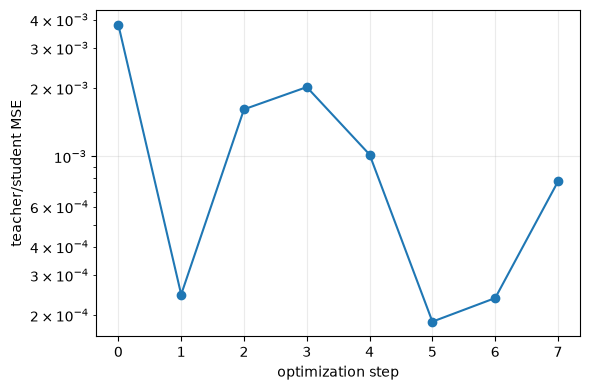

In [7]:
teacher = copy.deepcopy(layer).eval()
student = copy.deepcopy(layer).train()
with torch.no_grad():
    teacher.weight.normal_(mean=0.0, std=0.15)
    teacher.bias.fill_(0.05)
    student.weight.zero_()
    student.bias.zero_()
for parameter in teacher.parameters():
    parameter.requires_grad_(False)

training_maps = torch.randn(4, 1, len(cell_ids), device=device)
with torch.no_grad():
    targets = teacher(training_maps)
optimizer = torch.optim.Adam(student.parameters(), lr=5e-2)
losses = []
for step in range(8):
    optimizer.zero_grad()
    prediction = student(training_maps)
    train_loss = torch.mean((prediction - targets).square())
    train_loss.backward()
    optimizer.step()
    losses.append(train_loss.item())
    print(f"step {step:02d}: {losses[-1]:.6e}")

assert np.isfinite(losses).all()
assert min(losses[1:]) < losses[0]
plt.figure(figsize=(6, 4))
plt.semilogy(losses, marker="o")
plt.xlabel("optimization step")
plt.ylabel("teacher/student MSE")
plt.grid(True, alpha=0.25)
plt.tight_layout()

## NumPy interoperability

In [8]:
numpy_input = np.ones(len(cell_ids), dtype=np.float32)
numpy_output = layer(numpy_input)
assert isinstance(numpy_output, np.ndarray)
assert numpy_output.shape == numpy_input.shape
print("NumPy output:", numpy_output.shape, numpy_output.dtype)

NumPy output: (4682,) float32
